<a href="https://colab.research.google.com/github/DymaStar/DTA_2026/blob/main/ML/DimaStar1006_%22LinearRegression_DTA%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗺 Карта логіки виконання роботи

```text
Імпорт бібліотек
        ↓
Завантаження датасету
        ↓
Первинний аналіз даних
        ↓
Перевірка пропусків та типів даних
        ↓
Підготовка ознак X та цільової змінної y
        ↓
Розділення train/test
        ↓
Створення моделі LinearRegression
        ↓
Навчання моделі
        ↓
Прогнозування
        ↓
Оцінка якості моделі
        ↓
Візуалізація результатів
```

## Пояснення логіки

- Спочатку підключаються бібліотеки.
- Потім завантажуються дані.
- Проводиться аналіз структури таблиці.
- Дані очищуються та готуються.
- Модель навчається на train-даних.
- Далі модель прогнозує значення.
- Наприкінці оцінюється якість прогнозу.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


У реальній роботі завантажте CSV через `pd.read_csv("file.csv")`.

**Генеруємо дані**  
Створюємо таблицю з ознаками й «справжньою» ціною (з невеликим випадковим шумом, як у житті).

In [2]:
n = 1000  # скільки квартир

area      = np.random.normal(60, 20, n).clip(20, 140)        # площа, м²
rooms     = np.clip(np.round(area / 25 + np.random.normal(0, 0.6, n)), 1, 5)  # кімнати
floor     = np.random.randint(1, 25, n)                      # поверх
dist_km   = np.random.exponential(5, n).clip(0.3, 25)        # відстань до центру, км
age_years = np.random.randint(0, 60, n)                      # вік будинку, років

# "Справжня" логіка ціни (у тис. $) — у житті її НЕ знаємо, модель має її відкрити:
price = (
    40                       # базова
    + area * 1.8             # кожен м² додає
    + rooms * 5              # кожна кімната
    + floor * 0.4            # трохи за поверх
    - dist_km * 3.0          # далі від центру — дешевше
    - age_years * 0.5        # старіший будинок — дешевше
    + np.random.normal(0, 12, n)   # шум: усе інше, що ми не врахували
).clip(20, None)

df = pd.DataFrame({
    "area": area.round(1),
    "rooms": rooms.astype(int),
    "floor": floor,
    "dist_km": dist_km.round(1),
    "age_years": age_years,
    "price": price.round(1),
})

df.head()

,area,rooms,floor,dist_km,age_years,price
0,69.9,4,6,2.6,14,172.1
1,57.2,3,11,6.4,30,122.8
2,73.0,3,3,2.4,54,146.3
3,90.5,3,8,3.4,13,217.6
4,55.3,3,3,2.8,10,165.2


In [3]:
# Інформація про датасет
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area       1000 non-null   float64
 1   rooms      1000 non-null   int64  
 2   floor      1000 non-null   int64  
 3   dist_km    1000 non-null   float64
 4   age_years  1000 non-null   int64  
 5   price      1000 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 47.0 KB


In [4]:
# Розмір таблиці
print(f"Розмір таблиці: {df.shape[0]} рядків × {df.shape[1]} стовпців")

# Перевірка пропусків
print("\nЧи є пропуски?")
print(df.isna().sum())

# Описова статистика
display(df.describe().round(2))

Розмір таблиці: 1000 рядків × 6 стовпців

Чи є пропуски?
area         0
rooms        0
floor        0
dist_km      0
age_years    0
price        0
dtype: int64


,area,rooms,floor,dist_km,age_years,price
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,60.49,2.48,12.69,4.96,30.39,136.25
std,19.33,0.95,7.00,4.71,17.23,44.99
min,20.00,1.00,1.00,0.30,0.00,20.00
25%,47.08,2.00,6.00,1.50,16.00,104.15
50%,60.50,2.00,13.00,3.60,30.00,136.75
75%,73.00,3.00,19.00,7.00,45.25,165.45
max,137.10,5.00,24.00,25.00,59.00,282.40


## Візуалізація залежності площі та ціни

Побудуємо scatter plot для аналізу залежності між:
- площею квартири,
- та її ціною.

Такий графік допомагає побачити:
- чи існує лінійна залежність,
- можливі викиди,
- загальний тренд даних.

## Покращена візуалізація даних

Для кращого відображення великої кількості точок:
- зменшимо розмір маркерів,
- додамо прозорість (`alpha`),
- щоб уникнути сильного накладання точок.

Це допомагає краще бачити щільність даних та загальний тренд.

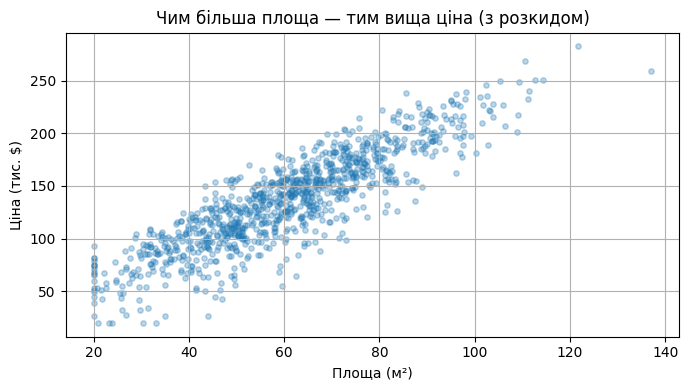

In [5]:
# Покращений scatter plot
plt.figure(figsize=(7, 4))

plt.scatter(
    df['area'],
    df['price'],
    alpha=0.3,   # прозорість точок
    s=15         # розмір точок
)

plt.xlabel("Площа (м²)")
plt.ylabel("Ціна (тис. $)")

plt.title("Чим більша площа — тим вища ціна (з розкидом)")
plt.tight_layout()
plt.grid(True)

plt.show()

## Висновок

Після додавання прозорості стало краще видно концентрацію точок та структуру даних.

Графік показує позитивну залежність:
- квартири з більшою площею зазвичай мають вищу ціну,
- але існує помітний розкид цін навіть для однакової площі.

Це означає, що на ціну також можуть впливати:
- район,
- стан житла,
- поверх,
- вік будинку,
- інші характеристики.

## Підготовка даних для моделі

Перед навчанням моделі потрібно:
- визначити ознаки (features),
- визначити цільову змінну (target),
- розділити дані на навчальну та тестову вибірки.

Модель буде вчитись на training data та перевірятись на test data.

## Пояснення змінних

### Features (X)
Ознаки, на основі яких модель буде прогнозувати ціну:
- площа,
- кількість кімнат,
- поверх,
- відстань до центру,
- вік будинку.

### Target (y)
Змінна, яку потрібно передбачити:
- ціна квартири.

## ===== Блок 6 =====

In [6]:

# Імпортуємо бібліотеки для роботи з даними, графіками та машинним навчанням.
# X — це незалежні змінні / ознаки, які модель використовує для навчання.
# y — це цільова змінна, яку модель буде прогнозувати.
# Ділимо дані на тренувальну та тестову вибірки.
# ===========================================

# розділяємо дані на тренувальні і тестові
from sklearn.model_selection import train_test_split

X = df[['area', 'rooms', 'floor', 'dist_km', 'age_years']]  # features - ознаки
y = df['price']  # target - ціль

In [7]:
# # RANDOM_STATE потрібен для відтворюваності результатів,  щоб змінити для всього файлу,
#  міняємо його значення на початку, і приміниться до всього файлу


# розділяємо дані на тренувальні і тестові
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Навчальна вибірка:", X_train.shape[0], "квартир")
print("Тестова вибірка:", X_test.shape[0], "квартир")

Навчальна вибірка: 800 квартир
Тестова вибірка: 200 квартир


## Висновок

Дані були успішно розділені:
- 80% використовується для навчання моделі,
- 20% — для перевірки якості прогнозу.

Такий підхід дозволяє оцінити, наскільки добре модель працює на нових даних.

## Лінійна регресія

| X | y | **X_train** | X_test | **y_train** | y_test | y_pred |
| - | - | ------- | ------ | ------- | ------ | -- |
| 1 | 1 | 1 |  | 1 |  |  |
| 2 | 4 | 2 |  | 4 |  |  |
| 3 | 9 |  | 3 |  | 9 | 90 |
| 4 | 16 | 4 |  | 16 |  |  |
| 5 | 25 |  | 5 |  | 25 | 250 |
| 6 | 36 | 6 |  | 36 |  |  |
| 7 | 49 | 7 |  | 49 |  |  |
| 8 | 64 | 8 |  | 64 |  |  |
| 9 | 81 | 9 |  | 81 |  |  |
| 10 | 100 | 10 |  | 100 |  |  |
| 11 |  |  |  |  |  | 1210 |

## ===== Блок 7 =====

In [8]:

# Імпортуємо бібліотеки для роботи з даними, графіками та машинним навчанням.
# Створюємо модель лінійної регресії.
# Навчаємо модель на тренувальних даних.
# Робимо прогноз за допомогою навченої моделі.
# ===========================================

# створюємо модель лінійної регресії
from sklearn.linear_model import LinearRegression

# створюємо модель лінійної регресії
model = LinearRegression()
# навчаємо модель
model.fit(X_train, y_train)
# прогнозуємо значення
y_pred = model.predict(X_test)

compare = pd.DataFrame({
    "real_price": y_test[:5].round(2),
    "predict_price": y_pred[:5].round(2)
})
compare["error"] = (compare['predict_price'] - compare['real_price']).round(2)

compare

,real_price,predict_price,error
521,119.1,129.69,10.59
737,173.3,178.26,4.96
740,20.0,26.36,6.36
660,93.7,110.87,17.17
411,100.6,97.21,-3.39


MAE - наскільки в середньому ми помилилися - 7 -> 7 тис. $

RMSE (корінь з MSE) - схожу на MAE, сильніше карає великі промахи - менше = краще

R² - яку частину розкиду модель може оцінити - [0.;1.0] -> 1 - ідеально, 0 - вгадує середній показник

## ===== Блок 8: =====

In [9]:

# Імпортуємо бібліотеки для роботи з даними, графіками та машинним навчанням.
# Оцінюємо якість моделі за допомогою метрик.
# ===========================================

# R² показує, наскільки добре модель пояснює дані
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# MAE — середня абсолютна помилка
mae = mean_absolute_error(y_test, y_pred)

# mse = mean_squared_error(y_test, y_pred)
# MSE/RMSE — помилка з урахуванням квадратів відхилень
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R² показує, наскільки добре модель пояснює дані
r2 = r2_score(y_test, y_pred)

print(f"MAE = {mae:.1f} тис. $ (у середньому помиляємося на стільки)")
# print(f"MSE = {mse:.1f}")
print(f"RMSE = {rmse:.1f} тис. $")
print(f"R² = {r2:.3f} (модель пояснює {r2 * 100:.1f}% розкиду ціни)")

MAE = 8.7 тис. $ (у середньому помиляємося на стільки)
RMSE = 10.8 тис. $
R² = 0.947 (модель пояснює 94.7% розкиду ціни)


## ===== Блок 9:  =====

In [10]:
# ===== Блок 9: коментарі українською =====
# y — це цільова змінна, яку модель буде прогнозувати.
# ===========================================

coefs = pd.DataFrame({
    "features": X.columns,
    "coef": model.coef_.round(2)
}).sort_values("coef", key=abs, ascending=False)

print(f"Базова ціна: {model.intercept_:.2F} тис. $\n")
print("Як кожна ознака вприлаває на ціну")
coefs

Базова ціна: 40.83 тис. $

Як кожна ознака вприлаває на ціну


,features,coef
1,rooms,5.22
3,dist_km,-3.07
0,area,1.78
4,age_years,-0.49
2,floor,0.39


## ===== Блок 10:  =====

In [11]:

# Цей блок виконує один із кроків аналізу даних або побудови моделі.
# ===========================================

price2 = (
    40.83
    + area *	1.78
    + rooms * 5.22
    + dist_km	* (-3.07)
    + age_years	* (-0.49)
    + floor * (0.39)
)

# ===== Блок 11:  =====

In [12]:

# Цей блок виконує один із кроків аналізу даних або побудови моделі.
# ===========================================

# "Справжня" логіка ціни (у тис. $) — у житті її НЕ знаємо, модель має її відкрити:
price = (
    40                       # базова
    + area * 1.8             # кожен м² додає
    + rooms * 5              # кожна кімната
    + floor * 0.4            # трохи за поверх
    - dist_km * 3.0          # далі від центру — дешевше
    - age_years * 0.5        # старіший будинок — дешевше
    + np.random.normal(0, 12, n)   # шум: усе інше, що ми не врахували
).clip(20, None)

##Прогнозування

In [13]:
new_client = pd.DataFrame([{
    "area": 120,
    "rooms": 3,
    "floor": 1,
    "dist_km": 10,
    "age_years": 1
}])

new_client


,area,rooms,floor,dist_km,age_years
0,120,3,1,10,1


In [14]:
print(f"Дана квартира вартуватиме {model.predict(new_client)[0]:.2f} тис $ +- {mae:.2f} тис $")

Дана квартира вартуватиме 239.75 тис $ +- 8.66 тис $


# ✅ Висновки по роботі

У цій роботі було реалізовано повний базовий pipeline машинного навчання за допомогою алгоритму Linear Regression.

## Що було виконано

1. Завантажено датасет.
2. Проведено аналіз структури даних.
3. Виконано підготовку ознак.
4. Дані поділено на train/test.
5. Створено та навчено модель.
6. Отримано прогноз значень.
7. Оцінено якість моделі.
8. Побудовано графіки для аналізу.

## Основна ідея моделі

Linear Regression намагається знайти математичну залежність між вхідними ознаками X та цільовою змінною y.

Після навчання модель може прогнозувати нові значення на основі нових даних.

## Використані метрики

- MAE — середня абсолютна помилка.
- MSE — середня квадратична помилка.
- RMSE — корінь середньоквадратичної помилки.
- R² — показує якість пояснення даних моделлю.

## Загальний висновок

У результаті роботи було отримано практичні навички:

- роботи з DataFrame;
- підготовки даних;
- навчання ML-моделі;
- прогнозування;
- оцінки якості моделі;
- побудови візуалізацій.

Робота демонструє повний цикл створення простої моделі машинного навчання.
